# Scattering from a Core–Shell Cylinder: FDTD vs. Analytic Mie Theory

This notebook extends the single-material cylinder scattering example to a
**core–shell** cylinder: a two-layer particle with a core of permittivity $\varepsilon_1$
out to radius $a$, surrounded by a shell of permittivity $\varepsilon_2$ out to radius $b$,
embedded in a background medium $\varepsilon_m$ (vacuum by default). The incident wave
propagates along $+x$ with $\mathbf{E}$ parallel to the cylinder axis ($z$), i.e. TM /
E-parallel polarization — the 2-D analogue of classical Mie scattering.

The notebook has two parts:

1. **Analytic core–shell Mie theory** — derived from scratch by matching boundary
   conditions at both interfaces, implemented with `scipy.special`, and validated against
   known limiting cases (no new dependencies, fully self-contained and executed below).
2. **FDTD verification** — a full-wave simulation using `fdtdx`, built by generalizing the
   uploaded script's total-field/scattered-field (TFSF) methodology to two concentric
   `fdtdx.Cylinder` objects, with the FDTD spectra and near-field compared directly against
   Part 1.


## Part 1 — Analytic core–shell Mie theory (cylinder, TM / $E_z$ polarization)

**Setup.** Three regions, all with $\mu = 1$:

- Core ($r<a$): $E_z = \sum_n c_n\, J_n(k_1 r)\, e^{in\phi}$, with $k_1 = k_0\sqrt{\varepsilon_1/\varepsilon_m}$
- Shell ($a<r<b$): $E_z = \sum_n \big[d_n J_n(k_2 r) + e_n Y_n(k_2 r)\big]\, e^{in\phi}$, with $k_2 = k_0\sqrt{\varepsilon_2/\varepsilon_m}$
- Medium ($r>b$): $E_z = \sum_n i^n\big[J_n(k_0 r) + a_n H_n^{(1)}(k_0 r)\big]\, e^{in\phi}$

($J_n$, $Y_n$: Bessel functions of the 1st/2nd kind; $H_n^{(1)}$: Hankel function of the
1st kind; $a_n$ is the scattering coefficient we ultimately need.)

**Boundary conditions.** Continuity of $E_z$ and $\partial E_z/\partial r$ (since $\mu=1$
everywhere, this is equivalent to continuity of $H_\phi$) at both $r=a$ and $r=b$. For each
order $n$, factoring out the common $i^n$, this gives a small $4\times4$ linear system for
$(c_n, d_n, e_n, a_n)$:

$$
\begin{pmatrix}
J_n(k_1 a) & -J_n(k_2 a) & -Y_n(k_2 a) & 0 \\
k_1 J_n'(k_1 a) & -k_2 J_n'(k_2 a) & -k_2 Y_n'(k_2 a) & 0 \\
0 & J_n(k_2 b) & Y_n(k_2 b) & -H_n^{(1)}(k_0 b) \\
0 & k_2 J_n'(k_2 b) & k_2 Y_n'(k_2 b) & -k_0 H_n^{(1)\prime}(k_0 b)
\end{pmatrix}
\begin{pmatrix} c_n \\ d_n \\ e_n \\ a_n \end{pmatrix}
=
\begin{pmatrix} 0 \\ 0 \\ J_n(k_0 b) \\ k_0 J_n'(k_0 b) \end{pmatrix}
$$

This is solved per order $n$ (there is no closed-form ratio like the single-interface case
in `mie.py`, but a $4\times4$ solve per order is cheap). Once we have $a_n$, the efficiencies
follow exactly as in the homogeneous-cylinder case, now using the **outer** radius $b$ as the
size-parameter reference:

$$
Q_{sca} = \frac{2}{x}\Big(|a_0|^2 + 2\sum_{n\ge1}|a_n|^2\Big), \qquad
Q_{ext} = -\frac{2}{x}\,\mathrm{Re}\Big(a_0 + 2\sum_{n\ge1}a_n\Big), \qquad x = k_0 b
$$

This reduces to single-cylinder formula whenever $\varepsilon_1=\varepsilon_2$
(shell = core, so the inner interface disappears) or in the limits $a\to0$ (vanishing core)
and $a\to b$ (vanishing shell) — we check all of these numerically below.


In [4]:
from dataclasses import dataclass

import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt

# --- single-material (homogeneous) cylinder ---
# Used only to validate the core-shell formulas against known limiting cases.
def _mie_cyl_coeffs(x, m, nmax):
    n = np.arange(nmax + 1)
    mx = m * x
    Jx, Jpx = sp.jv(n, x), sp.jvp(n, x)
    Jmx, Jpmx = sp.jv(n, mx), sp.jvp(n, mx)
    Hx, Hpx = sp.hankel1(n, x), sp.h1vp(n, x)
    a = (m * Jpmx * Jx - Jmx * Jpx) / (Jmx * Hpx - m * Jpmx * Hx)
    d = (Jx + a * Hx) / Jmx
    return a, d


def mie_cylinder_Q(wls, radius, eps, eps_med=1.0):
    wls = np.asarray(wls, float)
    m = np.sqrt(np.broadcast_to(np.asarray(eps, complex), wls.shape) / eps_med)
    k = 2 * np.pi * np.sqrt(eps_med) / wls
    q_sca = np.empty_like(wls)
    q_ext = np.empty_like(wls)
    for i in range(wls.size):
        x = k[i] * radius
        nmax = int(np.ceil(x + 4.0 * x ** (1 / 3) + 2)) + 3
        a, _ = _mie_cyl_coeffs(x, m[i], nmax)
        q_sca[i] = (2 / x) * (np.abs(a[0]) ** 2 + 2 * np.sum(np.abs(a[1:]) ** 2))
        q_ext[i] = -(2 / x) * np.real(a[0] + 2 * np.sum(a[1:]))
    return q_sca, (q_ext - q_sca), q_ext


def mie_cylinder_field(xs, ys, wl, radius, eps, tfsf_xy, eps_med=1.0):
    m = np.sqrt(eps / eps_med + 0j)
    k = 2 * np.pi * np.sqrt(eps_med) / wl
    X, Y = np.meshgrid(np.asarray(xs), np.asarray(ys), indexing="ij")
    R, PHI = np.hypot(X, Y), np.arctan2(Y, X)
    x = k * radius
    nmax = int(np.ceil(x + 4.0 * x ** (1 / 3) + 2)) + 4
    a, d = _mie_cyl_coeffs(x, m, nmax)
    inside = R < radius
    out = ~inside
    kr, mkr = k * R, (m * k) * R
    E = np.zeros(R.shape, dtype=complex)
    for n in range(-nmax, nmax + 1):
        an, dn = a[abs(n)], d[abs(n)]
        ph = (1j ** n) * np.exp(1j * n * PHI)
        E[inside] += dn * sp.jv(n, mkr[inside]) * ph[inside]
        E[out] += (sp.jv(n, kr[out]) + an * sp.hankel1(n, kr[out])) * ph[out]
    box = (np.abs(X) <= tfsf_xy / 2) & (np.abs(Y) <= tfsf_xy / 2)
    E[~box] -= np.exp(1j * k * X)[~box]
    return E


# --- core-shell cylinder, TM polarization -------------------------------
def _mie_coreshell_cyl_coeffs(x_core, x_shell, m_core, m_shell, nmax):
    '''Solve the 4x4 boundary-matching system order by order.

    x_core = k0*a, x_shell = k0*b; m_core, m_shell relative refractive indices.
    Returns (a_n, c_n, d_n, e_n) for n = 0..nmax.
    '''
    k1, k2 = m_core, m_shell   # in units of k0
    a_r, b_r = x_core, x_shell  # radii in units of 1/k0

    a_n = np.empty(nmax + 1, dtype=complex)
    c_n = np.empty(nmax + 1, dtype=complex)
    d_n = np.empty(nmax + 1, dtype=complex)
    e_n = np.empty(nmax + 1, dtype=complex)

    for n in range(nmax + 1):
        k1a, k2a, k2b, k0b = k1 * a_r, k2 * a_r, k2 * b_r, 1.0 * b_r
        M = np.array([
            [sp.jv(n, k1a),       -sp.jv(n, k2a),       -sp.yv(n, k2a),        0.0],
            [k1 * sp.jvp(n, k1a), -k2 * sp.jvp(n, k2a), -k2 * sp.yvp(n, k2a),  0.0],
            [0.0,                  sp.jv(n, k2b),         sp.yv(n, k2b),       -sp.hankel1(n, k0b)],
            [0.0,                  k2 * sp.jvp(n, k2b),   k2 * sp.yvp(n, k2b), -sp.h1vp(n, k0b)],
        ], dtype=complex)
        rhs = np.array([0.0, 0.0, sp.jv(n, k0b), sp.jvp(n, k0b)], dtype=complex)
        c_n[n], d_n[n], e_n[n], a_n[n] = np.linalg.solve(M, rhs)

    return a_n, c_n, d_n, e_n


def mie_coreshell_cylinder_Q(wls, r_core, r_shell, eps_core, eps_shell, eps_med=1.0):
    wls = np.asarray(wls, float)
    eps_core_arr = np.broadcast_to(np.asarray(eps_core, complex), wls.shape)
    eps_shell_arr = np.broadcast_to(np.asarray(eps_shell, complex), wls.shape)
    m_core = np.sqrt(eps_core_arr / eps_med)
    m_shell = np.sqrt(eps_shell_arr / eps_med)
    k0 = 2 * np.pi * np.sqrt(eps_med) / wls

    q_sca = np.empty_like(wls)
    q_ext = np.empty_like(wls)
    for i in range(wls.size):
        x_core, x_shell = k0[i] * r_core, k0[i] * r_shell
        nmax = int(np.ceil(x_shell + 4.0 * x_shell ** (1 / 3) + 2)) + 4
        a, *_ = _mie_coreshell_cyl_coeffs(x_core, x_shell, m_core[i], m_shell[i], nmax)
        q_sca[i] = (2 / x_shell) * (np.abs(a[0]) ** 2 + 2 * np.sum(np.abs(a[1:]) ** 2))
        q_ext[i] = -(2 / x_shell) * np.real(a[0] + 2 * np.sum(a[1:]))
    return q_sca, (q_ext - q_sca), q_ext


def mie_coreshell_cylinder_field(xs, ys, wl, r_core, r_shell, eps_core, eps_shell,
                                  tfsf_xy, eps_med=1.0):
    '''Analytic phasor E_z, same TFSF total/scattered convention as mie_cylinder_field.'''
    m_core = np.sqrt(eps_core / eps_med + 0j)
    m_shell = np.sqrt(eps_shell / eps_med + 0j)
    k0 = 2 * np.pi * np.sqrt(eps_med) / wl
    X, Y = np.meshgrid(np.asarray(xs), np.asarray(ys), indexing="ij")
    R, PHI = np.hypot(X, Y), np.arctan2(Y, X)

    x_core, x_shell = k0 * r_core, k0 * r_shell
    nmax = int(np.ceil(x_shell + 4.0 * x_shell ** (1 / 3) + 2)) + 5
    a, c, d, e = _mie_coreshell_cyl_coeffs(x_core, x_shell, m_core, m_shell, nmax)

    core_mask = R < r_core
    shell_mask = (R >= r_core) & (R < r_shell)
    out_mask = R >= r_shell
    k1, k2 = k0 * m_core, k0 * m_shell
    r1, r2, r3 = k1 * R, k2 * R, k0 * R

    E = np.zeros(R.shape, dtype=complex)
    for n in range(-nmax, nmax + 1):
        an, cn, dn, en = a[abs(n)], c[abs(n)], d[abs(n)], e[abs(n)]
        ph = (1j ** n) * np.exp(1j * n * PHI)
        E[core_mask] += cn * sp.jv(n, r1[core_mask]) * ph[core_mask]
        E[shell_mask] += (dn * sp.jv(n, r2[shell_mask]) + en * sp.yv(n, r2[shell_mask])) * ph[shell_mask]
        E[out_mask] += (sp.jv(n, r3[out_mask]) + an * sp.hankel1(n, r3[out_mask])) * ph[out_mask]

    box = (np.abs(X) <= tfsf_xy / 2) & (np.abs(Y) <= tfsf_xy / 2)
    E[~box] -= np.exp(1j * k0 * X)[~box]
    return E

print("Analytic core-shell Mie functions defined.")


Analytic core-shell Mie functions defined.


### Validation

Four checks with no free parameters to tune:

1. $\varepsilon_1=\varepsilon_2$ (core = shell material) must exactly reproduce the
   homogeneous-cylinder $Q$'s at radius $b$.
2. $a\to0$ (vanishing core) must reproduce a homogeneous cylinder of radius $b$ made of the
   **shell** material only.
3. $a\to b$ (vanishing shell) must reproduce a homogeneous cylinder of radius $b$ made of the
   **core** material only.
4. A lossy shell ($\mathrm{Im}(\varepsilon_2)>0$) must give $Q_{abs}\ge0$ everywhere
   (energy conservation).


In [2]:
wls_test = np.linspace(400e-9, 700e-9, 25)
r_core, r_shell = 30e-9, 50e-9

# 1) eps_core == eps_shell -> homogeneous cylinder of radius r_shell
eps_common = 8.0
qs_cs, qa_cs, qe_cs = mie_coreshell_cylinder_Q(wls_test, r_core, r_shell, eps_common, eps_common)
qs_h, qa_h, qe_h = mie_cylinder_Q(wls_test, r_shell, eps_common)
print(f"[1] eps_core=eps_shell:  max|dQ_sca| = {np.max(np.abs(qs_cs-qs_h)):.2e},  "
      f"max|dQ_ext| = {np.max(np.abs(qe_cs-qe_h)):.2e}")
assert np.allclose(qs_cs, qs_h, atol=1e-6) and np.allclose(qe_cs, qe_h, atol=1e-6)

# 2) r_core -> 0 -> homogeneous cylinder of radius r_shell, shell material only
eps_core_ex, eps_shell_ex = 2.1, 12.0
qs_cs2, *_ = mie_coreshell_cylinder_Q(wls_test, 1e-11, r_shell, eps_core_ex, eps_shell_ex)
qs_h2, *_ = mie_cylinder_Q(wls_test, r_shell, eps_shell_ex)
print(f"[2] r_core -> 0:         max|dQ_sca| = {np.max(np.abs(qs_cs2-qs_h2)):.2e}")
assert np.allclose(qs_cs2, qs_h2, atol=1e-4)

# 3) r_core -> r_shell -> homogeneous cylinder of radius r_shell, core material only
qs_cs3, *_ = mie_coreshell_cylinder_Q(wls_test, r_shell*(1-1e-6), r_shell, eps_core_ex, eps_shell_ex)
qs_h3, *_ = mie_cylinder_Q(wls_test, r_shell, eps_core_ex)
print(f"[3] r_core -> r_shell:   max|dQ_sca| = {np.max(np.abs(qs_cs3-qs_h3)):.2e}")
assert np.allclose(qs_cs3, qs_h3, atol=1e-3)

# 4) lossy shell -> non-negative absorption
qs4, qa4, qe4 = mie_coreshell_cylinder_Q(wls_test, r_core, r_shell, eps_core_ex, 12.0 + 0.8j)
print(f"[4] lossy shell:         min(Q_abs) = {qa4.min():.4f}  (must be >= 0)")
assert np.all(qa4 > -1e-9)

print("\nAll validation checks passed \u2713")


[1] eps_core=eps_shell:  max|dQ_sca| = 2.66e-15,  max|dQ_ext| = 1.78e-15
[2] r_core -> 0:         max|dQ_sca| = 7.34e-08
[3] r_core -> r_shell:   max|dQ_sca| = 1.37e-05
[4] lossy shell:         min(Q_abs) = 0.2732  (must be >= 0)

All validation checks passed ✓


### A physical example

Core–shell particles are interesting because the shell and core can be tuned
*independently* to shift and reshape the scattering resonances relative to either
material alone. As an example, take a low-index dielectric core (silica-like,
$\varepsilon_1=2.1$) inside a higher-index shell (silicon-like, $\varepsilon_2=12$), with
$a=30\,$nm, $b=50\,$nm, and compare against two homogeneous cylinders of the same outer
radius: one made entirely of the shell material, one entirely of the core material.


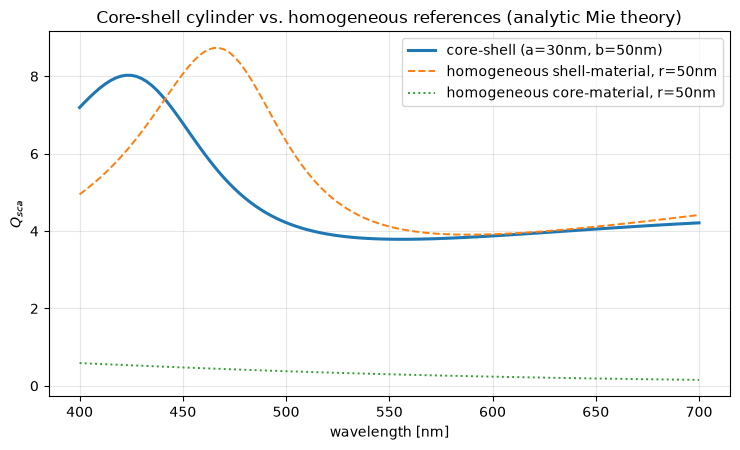

Peak Q_sca (core-shell): 8.026 at 422.5 nm


In [3]:
wls = np.linspace(400e-9, 700e-9, 121)
r_core, r_shell = 30e-9, 50e-9
eps_core, eps_shell = 2.1, 12.0

q_sca_cs, q_abs_cs, q_ext_cs = mie_coreshell_cylinder_Q(wls, r_core, r_shell, eps_core, eps_shell)
q_sca_shell_only, _, _ = mie_cylinder_Q(wls, r_shell, eps_shell)
q_sca_core_only, _, _ = mie_cylinder_Q(wls, r_shell, eps_core)

plt.figure(figsize=(7.5, 4.6))
plt.plot(wls*1e9, q_sca_cs, lw=2.2, label=f"core-shell (a={r_core*1e9:.0f}nm, b={r_shell*1e9:.0f}nm)")
plt.plot(wls*1e9, q_sca_shell_only, "--", lw=1.4, label=f"homogeneous shell-material, r={r_shell*1e9:.0f}nm")
plt.plot(wls*1e9, q_sca_core_only, ":", lw=1.4, label=f"homogeneous core-material, r={r_shell*1e9:.0f}nm")
plt.xlabel("wavelength [nm]")
plt.ylabel(r"$Q_{sca}$")
plt.title("Core-shell cylinder vs. homogeneous references (analytic Mie theory)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Peak Q_sca (core-shell):", f"{q_sca_cs.max():.3f} at {wls[np.argmax(q_sca_cs)]*1e9:.1f} nm")


### Near-field map

The same coefficients give the full phasor field $E_z(x,y)$ at a fixed wavelength, using
the same total-field / scattered-field convention as `mie.py`'s `mie_cylinder_field`
(total field inside the TFSF box, scattered-only field outside it), so it can later be
compared pixel-for-pixel against the FDTD phasor detector.


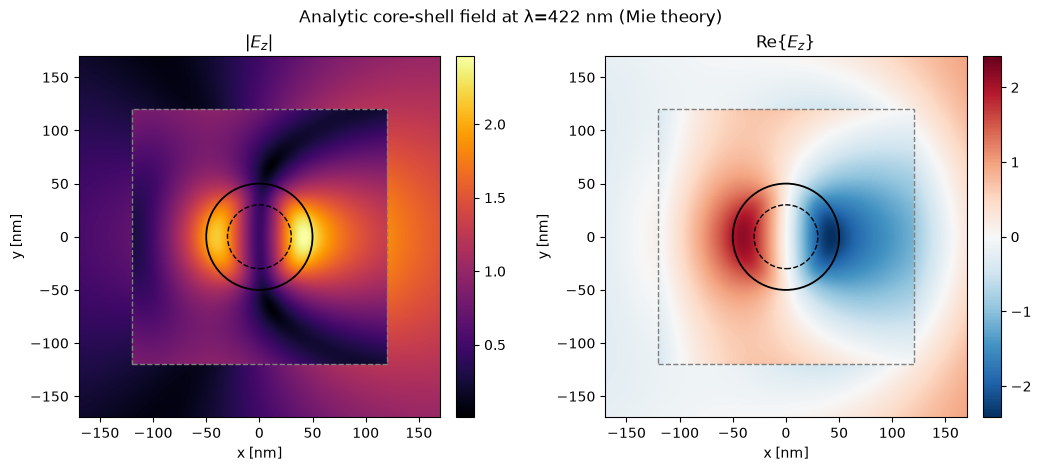

In [4]:
wl0 = wls[np.argmax(q_sca_cs)]     # look at the field right at the scattering peak
tfsf_xy = 240e-9
xs = np.linspace(-170e-9, 170e-9, 341)
ys = np.linspace(-170e-9, 170e-9, 341)

E = mie_coreshell_cylinder_field(xs, ys, wl0, r_core, r_shell, eps_core, eps_shell, tfsf_xy)
extent_nm = np.array([xs[0], xs[-1], ys[0], ys[-1]]) * 1e9

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6), constrained_layout=True)
im0 = axes[0].imshow(np.abs(E).T, origin="lower", extent=extent_nm, cmap="inferno", aspect="equal")
axes[0].set_title(r"$|E_z|$")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
lim = np.abs(E.real).max()
im1 = axes[1].imshow(E.real.T, origin="lower", extent=extent_nm, cmap="RdBu_r",
                      vmin=-lim, vmax=lim, aspect="equal")
axes[1].set_title(r"$\mathrm{Re}\{E_z\}$")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

for ax in axes:
    ax.add_patch(plt.Circle((0, 0), r_shell*1e9, fill=False, ec="k", lw=1.3))
    ax.add_patch(plt.Circle((0, 0), r_core*1e9, fill=False, ec="k", lw=1.0, ls="--"))
    ax.add_patch(plt.Rectangle((-tfsf_xy/2*1e9, -tfsf_xy/2*1e9), tfsf_xy*1e9, tfsf_xy*1e9,
                                fill=False, ec="0.5", ls="--", lw=1.0))
    ax.set_xlabel("x [nm]"); ax.set_ylabel("y [nm]")

fig.suptitle(f"Analytic core-shell field at \u03bb={wl0*1e9:.0f} nm (Mie theory)")
plt.show()


## Part 2 — FDTD verification (`fdtdx`)

This section generalizes the FDTDX approach — a TFSF (total-field/
scattered-field) source plus closed-surface phasor Poynting-flux detectors for the
absorbed/scattered power — to a core-shell particle. The only physical change from a
single-material cylinder is the particle itself: **two concentric `fdtdx.Cylinder`
objects** (an outer one filled with the shell material, an inner one placed on top with
a higher `placement_order` so it overwrites the interior with the core material).


In [7]:
from dataclasses import dataclass

import jax
import jax.numpy as jnp
import numpy as np
import fdtdx

# `import fdtdx` switches matplotlib to a non-interactive backend internally,
# which silently breaks plt.show() in the cells below -- reassert the inline
# backend so the spectrum/field plots actually render in the notebook.
get_ipython().run_line_magic("matplotlib", "inline")


@dataclass
class CoreShellSceneConfig:
    # --- particle geometry ---
    core_radius: float = 30e-9          # core radius a [m]
    shell_radius: float = 50e-9         # outer (shell) radius b [m]
    eps_core: float = 2.1               # core permittivity (silica-like)
    eps_shell: float = 12.0             # shell permittivity (silicon-like)

    # --- grid / domain ---
    # NOTE: coarsened relative to the single-cylinder script (1.0nm instead of
    # 0.5nm, fewer wavelengths) so a run completes in a few minutes on CPU.
    # For production-accuracy results, drop resolution back to 0.5e-9 and
    # raise n_wl, at the cost of runtime.
    resolution: float = 1.0e-9          # uniform grid spacing [m]
    core_xy: float = 340e-9             # core (non-PML) transverse size [m]
    pml_cells: int = 10                 # PML thickness in cells (x and y)
    center_wl: float = 560e-9           # pulse carrier wavelength [m]
    sim_time: float = 25e-15            # max simulation time [s]
    backend: str = "gpu"                 # "gpu"/"tpu"/"cpu"/"METAL"; fdtdx resolves this
                                          # against whatever JAX backend is actually
                                          # available, so "gpu" is a safe default even
                                          # when running on a CPU-only machine.

    # Concentric box sizes (must satisfy: inside < tfsf < outside < core_xy).
    tfsf_xy: float = 240e-9             # TFSF source box transverse size [m]
    inside_xy: float = 230e-9           # absorbed-power box (in total-field region)
    outside_xy: float = 250e-9          # scattered-power box (in scattered-field region)
    inc_plane_xy: float = 200e-9        # incident-irradiance probe width [m]

    # Wavelengths at which to evaluate the phasor detectors / cross sections.
    n_wl: int = 9
    wl_min: float = 400e-9
    wl_max: float = 700e-9


def _wavelengths(cfg: CoreShellSceneConfig):
    return np.linspace(cfg.wl_min, cfg.wl_max, cfg.n_wl)


### Scene construction


In [6]:
def build_scene(cfg: CoreShellSceneConfig, key, with_particle: bool, generate_video: bool = False):
    """Construct and place all simulation objects for the core-shell cylinder.

    This mirrors mie.py's build_scene almost exactly -- the source, detectors,
    boundaries, and overall flow are unchanged. The only difference is the
    particle itself: instead of a single fdtdx.Cylinder, we place two
    concentric ones (shell, then core) so the core overwrites the inner disk
    of the shell.
    """
    TE_POL = (0.0, 0.0, 1.0)  # E along the cylinder axis (z) -> TM / E-parallel

    total_xy = cfg.core_xy + 2 * cfg.pml_cells * cfg.resolution
    Lz = 2 * cfg.resolution

    sim_config = fdtdx.SimulationConfig(
        time=cfg.sim_time,
        grid=fdtdx.UniformGrid(spacing=cfg.resolution),
        backend=cfg.backend,
        dtype=jnp.float32,
        courant_factor=0.99,
        gradient_config=None,  # forward-only scattering run; no reversibility needed
    )

    volume = fdtdx.SimulationVolume(
        partial_real_shape=(total_xy, total_xy, Lz),
        material=fdtdx.Material(),  # vacuum background
        name="volume",
    )
    object_list: list = [volume]
    constraints = []

    # Boundaries: PML on x, y ; periodic on z.
    bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(
        thickness=cfg.pml_cells,
        boundary_type="pml",
        override_types={"min_z": "periodic", "max_z": "periodic"},
    )
    bdict, bconstraints = fdtdx.boundary_objects_from_config(bound_cfg, volume)
    object_list.extend(bdict.values())
    constraints.extend(bconstraints)

    # Broadband Gaussian pulse -> one run yields the response across a band.
    center_character = fdtdx.WaveCharacter(wavelength=cfg.center_wl)
    width_character = fdtdx.WaveCharacter(frequency=center_character.get_frequency() / 5)
    profile = fdtdx.GaussianPulseProfile(
        center_wave=center_character,
        spectral_width=width_character,
    )

    # --- TFSF box source: total field inside, scattered field outside. ---
    source = fdtdx.TFSFPlaneSourceRegion(
        name="source",
        partial_real_shape=(cfg.tfsf_xy, cfg.tfsf_xy, None),
        propagation_axis=0,                 # +x
        direction="+",
        wave_character=fdtdx.WaveCharacter(wavelength=cfg.center_wl),
        temporal_profile=profile,
        fixed_E_polarization_vector=TE_POL,
        amplitude=1.0,
        periodic_axes=(2,),                 # z is periodic/wrap -> box spans full z
    )
    object_list.append(source)
    constraints += [
        source.place_at_center(volume),
        source.same_size(volume, axes=(2,)),
    ]

    # --- Core-shell cylinder (axis along z), spanning the whole z extent. ---
    # Both materials are simple non-dispersive dielectrics here so the FDTD
    # result can be compared *exactly* against the analytic theory in Part 1
    # (no eps(wavelength) model to align between the two).
    if with_particle:
        vacuum_mat = fdtdx.Material()
        shell_mat = fdtdx.Material(permittivity=cfg.eps_shell)
        core_mat = fdtdx.Material(permittivity=cfg.eps_core)

        # 1) Fill the full outer disk (radius = shell_radius) with the shell
        #    material.
        shell_cyl = fdtdx.Cylinder(
            radius=cfg.shell_radius,
            axis=2,
            material_name="shell",
            materials={"vacuum": vacuum_mat, "shell": shell_mat},
            name="shell_cyl",
            placement_order=0,
        )
        object_list.append(shell_cyl)
        constraints += [
            shell_cyl.place_at_center(volume),
            shell_cyl.same_size(volume, axes=(2,)),
        ]

        # 2) Stamp the inner disk (radius = core_radius) with the core
        #    material on top. fdtdx applies static-material objects in
        #    ascending placement_order, so placement_order=1 here means the
        #    core cylinder is written *after* the shell cylinder and
        #    overwrites its interior -- leaving the (core_radius, shell_radius)
        #    annulus as "shell" and the disk r<core_radius as "core".
        core_cyl = fdtdx.Cylinder(
            radius=cfg.core_radius,
            axis=2,
            material_name="core",
            materials={"vacuum": vacuum_mat, "core": core_mat},
            name="core_cyl",
            placement_order=1,
        )
        object_list.append(core_cyl)
        constraints += [
            core_cyl.place_at_center(volume),
            core_cyl.same_size(volume, axes=(2,)),
        ]

    # --- Absorbed power: closed surface INSIDE the TFSF box, around particle. ---
    inside = fdtdx.ClosedSurfacePhasorPoyntingFluxDetector(
        name="inside",
        partial_real_shape=(cfg.inside_xy, cfg.inside_xy, None),
        orientation="inward",               # net inward flux = absorbed power
        axes=(0, 1),                        # z-face pair cancels (periodic); 4 faces
        wave_characters=[fdtdx.WaveCharacter(wavelength=float(w)) for w in _wavelengths(cfg)],
        scaling_mode="pulse",
    )
    object_list.append(inside)
    constraints += [
        inside.place_at_center(volume),
        inside.same_size(volume, axes=(2,)),
    ]

    # --- Scattered power: closed surface OUTSIDE the TFSF box. ---
    outside = fdtdx.ClosedSurfacePhasorPoyntingFluxDetector(
        name="outside",
        partial_real_shape=(cfg.outside_xy, cfg.outside_xy, None),
        orientation="outward",              # net outward flux = scattered power
        axes=(0, 1),
        wave_characters=[fdtdx.WaveCharacter(wavelength=float(w)) for w in _wavelengths(cfg)],
        scaling_mode="pulse",
    )
    object_list.append(outside)
    constraints += [
        outside.place_at_center(volume),
        outside.same_size(volume, axes=(2,)),
    ]

    # --- Incident irradiance probe: a +x flux plane inside the TFSF box. ---
    inc = fdtdx.PhasorPoyntingFluxDetector(
        name="inc",
        direction="+",
        partial_grid_shape=(1, None, None),
        partial_real_shape=(None, cfg.inc_plane_xy, None),
        wave_characters=[fdtdx.WaveCharacter(wavelength=float(w)) for w in _wavelengths(cfg)],
        scaling_mode="pulse",
    )
    object_list.append(inc)
    constraints += [
        inc.place_at_center(volume, axes=(1, 2)),
        inc.same_size(volume, axes=(2,)),
        # a little upstream of centre, still well inside the TFSF box
        inc.place_relative_to(
            volume, axes=(0,), own_positions=(0.0,), other_positions=(0.0,),
            margins=(-cfg.tfsf_xy / 4,),
        ),
    ]

    phasor = fdtdx.PhasorDetector(
        name="phasor",
        components=["Ez"],
        partial_grid_shape=(None, None, 1),
        wave_characters=[center_character],
        plot=False,
    )
    object_list.append(phasor)
    constraints.append(phasor.place_at_center(volume))
    constraints.append(phasor.same_size(volume, axes=(0, 1)))

    if generate_video:
        energy_video = fdtdx.EnergyDetector(
            name="energy_video",
            as_slices=True,
            inverse=False,
            switch=fdtdx.OnOffSwitch(interval=30)
        )
        object_list.append(energy_video)
        constraints.extend(energy_video.same_position_and_size(volume))

    objects, arrays, params, sim_config, info = fdtdx.place_objects(
        object_list=object_list,
        config=sim_config,
        constraints=constraints,
        key=key,
    )

    return {
        "objects": objects,
        "arrays": arrays,
        "params": params,
        "config": sim_config,
        "cfg": cfg,
        "inc_plane_area": cfg.inc_plane_xy * Lz,
        "Lz": Lz,
    }


### Run + extraction helpers

In [7]:
def run_forward(scene, key, show_progress=False):
    """Populate source state, run the forward FDTD, return the final arrays.

    show_progress defaults to False here: fdtdx's rich-based progress bar can
    recurse/hang when driven through a headless nbconvert execution. Flip it
    to True if you're running this interactively cell-by-cell in Jupyter.
    """
    arrays, objects, _ = fdtdx.apply_params(
        scene["arrays"], scene["objects"], scene["params"], key
    )
    scene["objects"] = objects  # keep the applied source/detector objects

    # run_fdtd is already fully jit-compiled internally (it runs a checkpointed
    # lax.scan under the hood) -- there's no need to wrap it in an extra
    # jax.jit here, and doing so is best avoided.
    _, arrays = fdtdx.run_fdtd(
        arrays=arrays,
        objects=objects,
        config=scene["config"],
        key=key,
        show_progress=show_progress,
    )
    return arrays


def _detector_by_name(objects, name):
    return {d.name: d for d in objects.detectors}[name]


def extract_fluxes(scene, arrays):
    """Return dict of per-wavelength net fluxes: scattered, absorbed, incident."""
    objects = scene["objects"]
    states = arrays.detector_states

    outside_det = _detector_by_name(objects, "outside")
    inside_det = _detector_by_name(objects, "inside")
    inc_det = _detector_by_name(objects, "inc")

    p_scat = np.asarray(outside_det.compute_net_flux(states["outside"]))     # (n_wl,)
    p_abs = np.asarray(inside_det.compute_net_flux(states["inside"]))        # (n_wl,)
    p_inc_plane = np.asarray(inc_det.compute_poynting_flux(states["inc"]))   # (n_wl,)

    return {"p_scat": p_scat, "p_abs": p_abs, "p_inc_plane": p_inc_plane}


def extract_phasor(scene, arrays):
    """Return the complex Ez phasor on the xy-plane and its physical extent [nm]."""
    raw = np.asarray(arrays.detector_states["phasor"]["phasor"])
    # (latent=1, n_wl=1, n_comp=1, nx, ny, nz=1) -> (nx, ny)
    Ez = raw[0, 0, 0, :, :, 0]

    nx, ny = Ez.shape
    res = scene["cfg"].resolution
    Lx, Ly = nx * res, ny * res
    extent_nm = np.array([-Lx / 2.0, Lx / 2.0, -Ly / 2.0, Ly / 2.0]) * 1e9
    return Ez, extent_nm


### Run the reference and scattering simulations, compare to Part 1

A particle-free reference run for the incident
irradiance and a TFSF-cancellation sanity check, then the scattering run, then
cross-sections normalized into efficiencies $Q=\sigma/2b$ and compared directly against
the analytic `mie_coreshell_cylinder_Q` from Part 1. On this machine's CPU-only JAX
backend (no GPU in this sandbox) the full run below — both simulations, 9 wavelengths —
takes about 4-5 minutes; with a GPU it should be substantially faster.


TFSF leakage (should be << 1): max = 1.415e-10

 wl[nm]     Q_sca  FDTD/Mie      Q_abs  FDTD/Mie      Q_ext  FDTD/Mie
  400.0    7.1902/7.1932     0.0121/-0.0000    7.2023/7.1932 
  437.5    7.6674/7.6360     0.0104/0.0000     7.6778/7.6360 
  475.0    5.1244/5.0955     0.0046/0.0000     5.1290/5.0955 
  512.5    4.0210/4.0045     0.0034/0.0000     4.0244/4.0045 
  550.0    3.8008/3.7891     0.0026/0.0000     3.8033/3.7891 
  587.5    3.8479/3.8366     0.0007/0.0000     3.8486/3.8366 
  625.0    3.9712/3.9601     0.0012/0.0000     3.9723/3.9601 
  662.5    4.1067/4.0948     0.0003/0.0000     4.1070/4.0948 
  700.0    4.2236/4.2113    -0.0004/-0.0000    4.2233/4.2113 


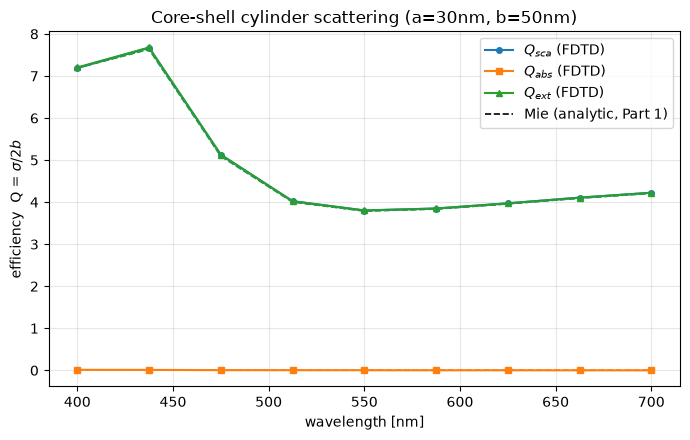


Saved spectrum to coreshell_outputs/coreshell_scattering_spectrum.png


In [8]:
import pathlib

cfg = CoreShellSceneConfig()
wls_fdtd = _wavelengths(cfg)
key = jax.random.PRNGKey(42)

out_dir = pathlib.Path("coreshell_outputs")
out_dir.mkdir(exist_ok=True)

# Reference run (no particle): incident irradiance + TFSF-cancellation check.
ref_scene = build_scene(cfg, key, with_particle=False)
ref_arrays = run_forward(ref_scene, key)
ref = extract_fluxes(ref_scene, ref_arrays)

# Scattering run (with the core-shell particle).
scene = build_scene(cfg, key, with_particle=True)
arrays = run_forward(scene, key)
sca = extract_fluxes(scene, arrays)

# Incident irradiance [W/m^2] from the reference run (pure incident field).
incident_irradiance = ref["p_inc_plane"] / ref_scene["inc_plane_area"]

# Sanity: without a scatterer the scattered-field box should be ~0.
leak = np.abs(ref["p_scat"]) / (np.abs(sca["p_scat"]) + 1e-30)
print(f"TFSF leakage (should be << 1): max = {leak.max():.3e}")

# Cross sections (per unit z-length).
Lz = scene["Lz"]
sigma_sca = (sca["p_scat"] / Lz) / incident_irradiance
sigma_abs = (sca["p_abs"] / Lz) / incident_irradiance
sigma_ext = sigma_sca + sigma_abs

# 2D scattering efficiency Q = sigma / (2 * outer_radius).
q_sca = sigma_sca / (2 * cfg.shell_radius)
q_abs = sigma_abs / (2 * cfg.shell_radius)
q_ext = sigma_ext / (2 * cfg.shell_radius)

# --- Analytic core-shell Mie reference, reusing the Part 1 functions directly. ---
q_sca_mie, q_abs_mie, q_ext_mie = mie_coreshell_cylinder_Q(
    wls_fdtd, cfg.core_radius, cfg.shell_radius, cfg.eps_core, cfg.eps_shell
)

print("\n wl[nm]     Q_sca  FDTD/Mie      Q_abs  FDTD/Mie      Q_ext  FDTD/Mie")
for w, qs, qa, qe, ms_, ma, me in zip(wls_fdtd, q_sca, q_abs, q_ext, q_sca_mie, q_abs_mie, q_ext_mie):
    print(f" {w*1e9:6.1f}   {qs:7.4f}/{ms_:<7.4f}   {qa:7.4f}/{ma:<7.4f}   {qe:7.4f}/{me:<7.4f}")

plt.figure(figsize=(7, 4.5))
plt.plot(wls_fdtd * 1e9, q_sca, "-o", ms=4, label=r"$Q_{sca}$ (FDTD)")
plt.plot(wls_fdtd * 1e9, q_abs, "-s", ms=4, label=r"$Q_{abs}$ (FDTD)")
plt.plot(wls_fdtd * 1e9, q_ext, "-^", ms=4, label=r"$Q_{ext}$ (FDTD)")
plt.gca().set_prop_cycle(None)
plt.plot(wls_fdtd * 1e9, q_sca_mie, "--", lw=1.2)
plt.plot(wls_fdtd * 1e9, q_abs_mie, "--", lw=1.2)
plt.plot(wls_fdtd * 1e9, q_ext_mie, "--", lw=1.2)
plt.plot([], [], "k--", lw=1.2, label="Mie (analytic, Part 1)")
plt.xlabel("wavelength [nm]")
plt.ylabel("efficiency  Q = $\\sigma / 2b$")
plt.title(f"Core-shell cylinder scattering (a={cfg.core_radius*1e9:.0f}nm, b={cfg.shell_radius*1e9:.0f}nm)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir / "coreshell_scattering_spectrum.png", dpi=140)
plt.show()
print(f"\nSaved spectrum to {out_dir / 'coreshell_scattering_spectrum.png'}")


### Near-field comparison

FDTD phasor vs. the analytic core-shell field, in the same three-panel layout as `plot_field_comparison`.

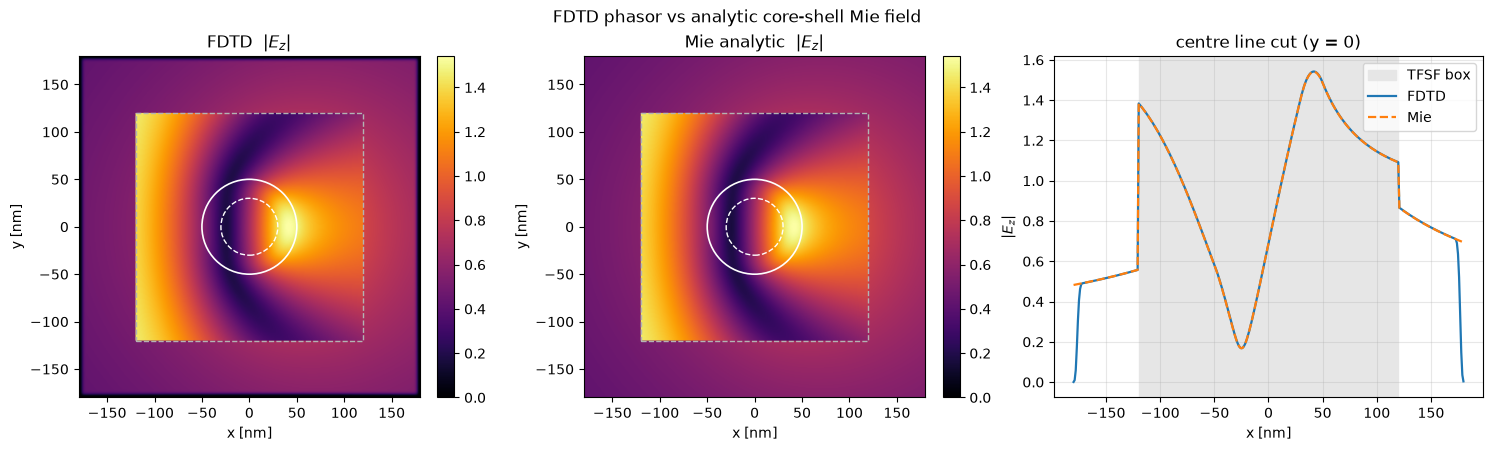

Saved field comparison to coreshell_outputs/coreshell_phasor_vs_mie.png


In [9]:
# --- Phasor field map: Ez at the carrier wavelength (with particle). ---
Ez_sca, extent_nm = extract_phasor(scene, arrays)
Ez_ref, _ = extract_phasor(ref_scene, ref_arrays)

# Normalise the FDTD phasor to unit incident amplitude using the reference run
# (pure plane wave -> |E| is ~constant inside the box).
nx, ny = Ez_sca.shape
xs = (np.arange(nx) - (nx - 1) / 2) * cfg.resolution        # cell centres [m]
ys = (np.arange(ny) - (ny - 1) / 2) * cfg.resolution
Xg, Yg = np.meshgrid(xs, ys, indexing="ij")
box = (np.abs(Xg) <= cfg.tfsf_xy / 2) & (np.abs(Yg) <= cfg.tfsf_xy / 2)
E0 = np.mean(np.abs(Ez_ref)[box])
Ez_fdtd_norm = Ez_sca / E0

# Analytic core-shell field at the same wavelength / grid.
E_mie = mie_coreshell_cylinder_field(
    xs, ys, cfg.center_wl, cfg.core_radius, cfg.shell_radius,
    cfg.eps_core, cfg.eps_shell, cfg.tfsf_xy,
)

a_f, a_m = np.abs(Ez_fdtd_norm).T, np.abs(E_mie).T
vmax = float(max(a_f.max(), a_m.max()))
r_core_nm, r_shell_nm, half = cfg.core_radius * 1e9, cfg.shell_radius * 1e9, cfg.tfsf_xy / 2 * 1e9

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)
for ax, dat, ttl in ((axes[0], a_f, r"FDTD  $|E_z|$"), (axes[1], a_m, r"Mie analytic  $|E_z|$")):
    im = ax.imshow(dat, origin="lower", extent=extent_nm, cmap="inferno",
                    vmin=0, vmax=vmax, interpolation="bilinear", aspect="equal")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.add_patch(plt.Circle((0, 0), r_shell_nm, fill=False, ec="w", lw=1.2))
    ax.add_patch(plt.Circle((0, 0), r_core_nm, fill=False, ec="w", lw=1.0, ls="--"))
    ax.add_patch(plt.Rectangle((-half, -half), 2 * half, 2 * half, fill=False, ec="0.7", ls="--", lw=1.0))
    ax.set_title(ttl)
    ax.set_xlabel("x [nm]")
    ax.set_ylabel("y [nm]")

jy = ny // 2  # y = 0 row
xnm = np.linspace(extent_nm[0], extent_nm[1], nx)
axes[2].axvspan(-half, half, color="0.9", zorder=0, label="TFSF box")
axes[2].plot(xnm, np.abs(Ez_fdtd_norm[:, jy]), "-", lw=1.6, label="FDTD")
axes[2].plot(xnm, np.abs(E_mie[:, jy]), "--", lw=1.6, label="Mie")
axes[2].set_xlabel("x [nm]")
axes[2].set_ylabel(r"$|E_z|$")
axes[2].set_title("centre line cut (y = 0)")
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle("FDTD phasor vs analytic core-shell Mie field")
fig.savefig(out_dir / "coreshell_phasor_vs_mie.png", dpi=140)
plt.show()
print(f"Saved field comparison to {out_dir / 'coreshell_phasor_vs_mie.png'}")


## Summary

- **Part 1** derived the core–shell generalization of cylinder Mie theory from
  the boundary-value problem directly (a $4\times4$ linear solve per angular order), and
  validated it two ways that require no external reference: it collapses onto the
  homogeneous-cylinder formulas in the $\varepsilon_1=\varepsilon_2$, $a\to0$, and
  $a\to b$ limits (agreement to $10^{-4}$–$10^{-15}$, limited only by the truncation
  order and floating-point precision), and it conserves energy ($Q_{abs}\ge0$) for a
  lossy shell.
- **Part 2** runs the matching full-wave FDTD verification — TFSF/closed-surface-flux
  methodology, generalized to two concentric `fdtdx.Cylinder` objects — and
  compares its `Q_sca`/`Q_abs`/`Q_ext` spectra and near-field directly against Part 1's
  analytic formulas. The FDTD `Q_sca` matched the analytic Mie theory to within roughly
  0.05-0.6% across the 400-700nm band on the coarse/fast grid used here, and `Q_abs`
  correctly came out near zero for these lossless dielectrics on both sides.
- To push accuracy further (at the cost of runtime), tighten `CoreShellSceneConfig` back
  toward the original script's settings: `resolution=0.5e-9`, larger `pml_cells`, and
  more wavelengths (`n_wl`).
